# Ro-Bust AI: AIGC Image Detector

### How to Run this Notebook?
1. Setup
2. Download ALL datasets (CIFAKE, SID_Set, Midjourney/DALL-E/SD) — this is the only section that pulls data over the network
3. Robustness transforms
4. Build datasets + combine everything + build the dual-branch model
5. Train
6. Evaluate clean vs. transformed (robustness table)
7. Run inference on your own images + save submission JSON

**Before running:** Runtime > Change runtime type > GPU (T4).

**Re-running note:** Section 2 only needs to run ONCE per Colab session. CIFAKE and the Midjourney/DALL-E/SD dataset are cached to disk after the first download, so re-running that cell is fast. SID_Set is streamed into memory as a Python list — re-running it re-downloads over the network, so avoid re-running it unless you've restarted your runtime (which wipes everything and forces a fresh pull of all three).

## 1. Setup

In [1]:
!pip install -q kagglehub timm datasets

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, WeightedRandomSampler
import timm
from torchvision import transforms
from PIL import Image, ImageFilter, ImageOps
import numpy as np
import kagglehub
from datasets import load_dataset
from huggingface_hub import HfApi
import os, glob, random, io, json, copy
from sklearn.metrics import roc_auc_score, accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Global seeding — nothing in the original notebook fixed a seed anywhere,
# so which images ended up in train vs. test, which augmentation got picked
# per image, and the final accuracy/AUC all varied run to run. Fixing this
# makes the 70/30 split (Section 4) and the reported metrics reproducible.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


Using device: cuda


## 2. Download all datasets

Everything that touches the network lives here: CIFAKE (Kaggle), SID_Set (streamed from HuggingFace), and the Midjourney/DALL-E/Stable Diffusion set (HuggingFace). Nothing here builds PyTorch `Dataset` objects yet — that happens in Section 4, once transforms are defined. This just gets the raw data in hand.

### 2a. CIFAKE

First run may prompt a Kaggle login link — click it, log in with a free Kaggle account. Cached after that.

In [2]:
DATA_PATH = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print('CIFAKE downloaded to:', DATA_PATH)

for root, dirs, files in os.walk(DATA_PATH):
    level = root.replace(DATA_PATH, '').count(os.sep)
    label = f'{"  "*level}{os.path.basename(root)}'
    print(f'{label}  ({len(files)} files)' if files else label)
    if level > 1:
        dirs.clear()

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
CIFAKE downloaded to: /kaggle/input/cifake-real-and-ai-generated-synthetic-images
cifake-real-and-ai-generated-synthetic-images
  test
    FAKE  (10000 files)
    REAL  (10000 files)
  train
    FAKE  (50000 files)
    REAL  (50000 files)


### 2b. SID_Set

SID_Set is huge (140GB total), so we STREAM it and only keep a manageable number of examples per class, held in memory as `sidset_samples`. Labels: 0 = real, 1 = full_synthetic, 2 = tampered — we keep 0 and 1, skip "tampered" for now.

In [3]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [4]:
sidset_stream = load_dataset("saberzl/SID_Set", split="train", streaming=True).shuffle(seed=42, buffer_size=10000)

# NOTE: with the new WeightedRandomSampler in Section 4, every source dataset
# gets EQUAL total pull on the model regardless of its raw sample count — so
# raising this number now directly buys more distinct examples per epoch for
# this source (rather than the same handful of images being resampled with
# replacement more often). If you have network/runtime budget to spare, this
# is one of the cheapest levers for closing the AUC gap on modern generators.
SIDSET_SAMPLES_PER_CLASS = 1500
sidset_samples = {0: [], 1: []}

for example in sidset_stream:
    label = example['label']
    if label == 0 and len(sidset_samples[0]) < SIDSET_SAMPLES_PER_CLASS:
        sidset_samples[0].append((example['image'].convert('RGB').resize((256, 256)), 0))
    elif label == 1 and len(sidset_samples[1]) < SIDSET_SAMPLES_PER_CLASS:
        sidset_samples[1].append((example['image'].convert('RGB').resize((256, 256)), 1))
    if len(sidset_samples[0]) >= SIDSET_SAMPLES_PER_CLASS and len(sidset_samples[1]) >= SIDSET_SAMPLES_PER_CLASS:
        break

print(f"Collected {len(sidset_samples[0])} real + {len(sidset_samples[1])} fake from SID_Set")


README.md:   0%|          | 0.00/3.30k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

Collected 1500 real + 1500 fake from SID_Set


### 2c. Midjourney / DALL-E / Stable Diffusion set

Targets modern, photorealistic generators (closer to what tools like ChatGPT's image generator produce). Loaded via explicit parquet file paths since this repo's auto-detection is unreliable.

In [5]:
mj_dataset = load_dataset(
    "parquet",
    data_files={
        "train": [
            "https://huggingface.co/datasets/julienlucas/midjourney-dalle-sd-dataset/resolve/main/data/train-00000-of-00003.parquet",
            "https://huggingface.co/datasets/julienlucas/midjourney-dalle-sd-dataset/resolve/main/data/train-00001-of-00003.parquet",
            "https://huggingface.co/datasets/julienlucas/midjourney-dalle-sd-dataset/resolve/main/data/train-00002-of-00003.parquet",
        ],
        "test": "https://huggingface.co/datasets/julienlucas/midjourney-dalle-sd-dataset/resolve/main/data/test-00000-of-00001.parquet",
    }
)
print(f"Midjourney/DALL-E/SD dataset — train: {len(mj_dataset['train'])}, test: {len(mj_dataset['test'])}")

data/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  396MB            

data/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  374MB            

data/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  876MB            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  346MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Midjourney/DALL-E/SD dataset — train: 5000, test: 1000


## 3. Robustness transforms

Implements the hackathon's augmentation table. Used two ways: randomly during **training** (so the model learns to survive them), and as fixed conditions during **evaluation** (for a clean comparison table).

In [6]:
def jpeg_compress(img, quality=50):
    buf = io.BytesIO()
    img.convert('RGB').save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return Image.open(buf).convert('RGB')

def gaussian_blur(img, sigma=1.0):
    return img.filter(ImageFilter.GaussianBlur(radius=sigma))

def resize_down_up(img, scale=0.5):
    w, h = img.size
    small = img.resize((max(1,int(w*scale)), max(1,int(h*scale))), Image.BILINEAR)
    return small.resize((w, h), Image.BILINEAR)

def gaussian_noise(img, sigma=0.05):
    arr = np.array(img).astype(np.float32) / 255.0
    noise = np.random.normal(0, sigma, arr.shape)
    noisy = np.clip(arr + noise, 0, 1) * 255.0
    return Image.fromarray(noisy.astype(np.uint8))

def color_jitter_fn(img, factor=0.2):
    jitter = transforms.ColorJitter(brightness=factor, contrast=factor, saturation=factor)
    return jitter(img)

def center_crop_fn(img, crop_pct=0.8):
    w, h = img.size
    new_w, new_h = int(w*crop_pct), int(h*crop_pct)
    left, top = (w-new_w)//2, (h-new_h)//2
    return img.crop((left, top, left+new_w, top+new_h)).resize((w,h), Image.BILINEAR)

def webp_compress(img, quality=80):
    buf = io.BytesIO()
    img.convert('RGB').save(buf, format='WEBP', quality=quality)
    buf.seek(0)
    return Image.open(buf).convert('RGB')

def png_roundtrip(img):
    """Re-encode through PNG at native resolution — teaches the model to handle
    the raw, uncompressed generator output that's currently causing false negatives."""
    buf = io.BytesIO()
    img.convert('RGB').save(buf, format='PNG')
    buf.seek(0)
    return Image.open(buf).convert('RGB')

def random_rotation(img, degrees=15):
    return img.rotate(random.uniform(-degrees, degrees), fillcolor=(128,128,128))

def random_flip(img):
    return img.transpose(Image.FLIP_LEFT_RIGHT) if random.random() > 0.5 else img


# --- Format-bias fix -------------------------------------------------------
# WHY the detector was misclassifying non-JPEG images despite already having
# jpeg/webp/png augmentations: the old TRAIN_AUGS was a single flat list of
# ~11 unrelated transforms, and every training step picked exactly ONE of
# them with `random.choice(TRAIN_AUGS)` (including a no-op identity option).
# That means on any given epoch, format re-encoding (jpeg/webp/png) only had
# roughly a 3-in-11 chance of touching a given image — most images were seen
# mostly in whatever format they originally happened to be stored in on disk.
#
# That matters because real-photo datasets are overwhelmingly JPEG-sourced
# while AI-generator datasets are overwhelmingly saved as lossless PNG. A
# model trained mostly on native formats can shortcut-learn "has JPEG
# quantization artifacts => real" instead of learning genuine synthetic-vs-
# real cues — a well-documented failure mode for AIGC detectors. That
# shortcut fails immediately on a real photo saved as WEBP/PNG, or an AI
# image re-saved as JPEG (e.g. after upload to a site that recompresses it).
#
# The fix: split augmentation into two independent stages instead of one
# mutually-exclusive pick.
#   1. FORMAT stage — ALWAYS applied, to every image, every epoch. One of
#      {identity, JPEG, WEBP, PNG-roundtrip} chosen uniformly at random. This
#      decorrelates on-disk format from label because both classes now see
#      every format with equal, guaranteed frequency (not "maybe, if
#      random.choice happens to land on it").
#   2. DISTORTION stage — applied on TOP of the format stage with independent
#      probability, and can stack (e.g. blur + rotate together), which is
#      closer to how real images get mangled (resized, then re-uploaded,
#      then re-compressed) than picking exactly one distortion in isolation.

FORMAT_AUGS = [
    lambda img: img,                                     # keep native format/artifacts
    lambda img: jpeg_compress(img, random.choice([90, 70, 50, 30])),
    lambda img: webp_compress(img, random.choice([90, 80, 70])),
    lambda img: png_roundtrip(img),
]

DISTORTION_AUGS = [
    lambda img: gaussian_blur(img, random.choice([0.5, 1.0, 2.0])),
    lambda img: resize_down_up(img, random.choice([0.5, 0.25])),
    lambda img: gaussian_noise(img, random.choice([0.02, 0.05, 0.10])),
    lambda img: color_jitter_fn(img, 0.2),
    lambda img: center_crop_fn(img, 0.8),
    lambda img: random_rotation(img),
    lambda img: random_flip(img),
]

def apply_train_augmentation(img):
    img = random.choice(FORMAT_AUGS)(img)      # stage 1: always runs
    if random.random() < 0.7:                  # stage 2: usually one distortion
        img = random.choice(DISTORTION_AUGS)(img)
    if random.random() < 0.25:                 # sometimes a second, stacked on top
        img = random.choice(DISTORTION_AUGS)(img)
    return img


EVAL_TRANSFORMS = {
    'clean': lambda img: img,
    'jpeg_q30': lambda img: jpeg_compress(img, 30),
    'webp_q70': lambda img: webp_compress(img, 70),
    'png_roundtrip': lambda img: png_roundtrip(img),
    'blur_s2.0': lambda img: gaussian_blur(img, 2.0),
    'resize_0.25x': lambda img: resize_down_up(img, 0.25),
    'noise_s0.10': lambda img: gaussian_noise(img, 0.10),
    'color_jitter': lambda img: color_jitter_fn(img, 0.2),
    'center_crop_80': lambda img: center_crop_fn(img, 0.8),
}
print('Transforms ready.')


Transforms ready.


## 4. Build datasets + combine + build model

This is where the raw data from Section 2 gets wrapped into PyTorch `Dataset` objects and merged together, and where the dual-branch (spatial + frequency) model gets built.

In [7]:
IMG_SIZE = 224

base_preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def load_and_fix(item):
    img = item if isinstance(item, Image.Image) else Image.open(item)
    img = ImageOps.exif_transpose(img)
    return img.convert('RGB')


class AIGCDataset(Dataset):
    def __init__(self, samples, augment=False):
        self.samples = samples
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item, label = self.samples[idx]
        img = load_and_fix(item)
        if self.augment:
            img = apply_train_augmentation(img)
        return base_preprocess(img.convert('RGB')), label


# --- Unified, explicit 70/30 split --------------------------------------
# Previously each source used a DIFFERENT, mostly-implicit ratio: CIFAKE
# relied on Kaggle's own train/ vs test/ folder split, SID_Set used an
# 85/15 split, and Midjourney+ relied on the HF repo's own predefined
# train/test parquet files — none of them consistently 70/30, and no single
# place controlled the ratio. Now every source is pooled from ALL of its
# raw data and re-split ourselves, stratified by class, at one explicit
# constant.
TRAIN_FRAC = 0.70          # >= 70% train / <= 30% test, as requested
VAL_FRAC_OF_TRAIN = 0.15   # carved OUT of the train side only, for early
                           # stopping / best-checkpoint selection — this does
                           # NOT change the 70/30 train/test ratio itself

def stratified_split(samples, train_frac, seed):
    """Splits a (item, label) list into (train, holdout), stratified per
    class so both class balance and the exact requested ratio are preserved
    regardless of how lopsided the source data is."""
    rng = random.Random(seed)
    by_class = {}
    for item, label in samples:
        by_class.setdefault(label, []).append((item, label))
    train, holdout = [], []
    for label, group in by_class.items():
        group = group[:]
        rng.shuffle(group)
        cut = int(len(group) * train_frac)
        train += group[:cut]
        holdout += group[cut:]
    rng.shuffle(train)
    rng.shuffle(holdout)
    return train, holdout

def split_train_val_test(samples, train_frac=TRAIN_FRAC, val_frac_of_train=VAL_FRAC_OF_TRAIN, seed=42):
    train_full, test = stratified_split(samples, train_frac, seed)
    train, val = stratified_split(train_full, 1 - val_frac_of_train, seed + 1)
    return train, val, test


# --- CIFAKE: pool BOTH the train/ and test/ folders Kaggle gives us, then
# re-split ourselves. max_per_class=18000 keeps the same total CIFAKE volume
# this notebook used before (15000 train + 3000 test = 18000/class). ---
def list_cifake_samples(root_dir, max_per_class=None):
    samples = []
    for label, folder in [(0, 'REAL'), (1, 'FAKE')]:
        files = sorted(glob.glob(os.path.join(root_dir, 'train', folder, '*'))) + \
                sorted(glob.glob(os.path.join(root_dir, 'test', folder, '*')))
        if max_per_class:
            files = files[:max_per_class]
        samples += [(f, label) for f in files]
    return samples

cifake_all = list_cifake_samples(DATA_PATH, max_per_class=18000)
cifake_train, cifake_val, cifake_test = split_train_val_test(cifake_all)

# --- SID_Set (from the raw sidset_samples collected in Section 2b) ---
sidset_all = sidset_samples[0] + sidset_samples[1]
sidset_train, sidset_val, sidset_test = split_train_val_test(sidset_all)

# --- Midjourney/DALL-E/SD: pool BOTH HF-provided splits, then re-split
# ourselves the same way as the other two sources. ---
def list_mj_samples(hf_dataset):
    samples = []
    for split_name in ['train', 'test']:
        for example in hf_dataset[split_name]:
            img = example['image'].convert('RGB').resize((256, 256))
            our_label = 0 if example['label'] == 'real' else 1  # this dataset uses 0=fake,1=real — flip to match ours
            samples.append((img, our_label))
    return samples

mj_all = list_mj_samples(mj_dataset)
mj_train, mj_val, mj_test = split_train_val_test(mj_all)

# --- Combine everything ---
train_ds = ConcatDataset([
    AIGCDataset(cifake_train, augment=True),
    AIGCDataset(sidset_train, augment=True),
    AIGCDataset(mj_train, augment=True),
])
val_ds = ConcatDataset([
    AIGCDataset(cifake_val, augment=False),
    AIGCDataset(sidset_val, augment=False),
    AIGCDataset(mj_val, augment=False),
])
test_ds = ConcatDataset([
    AIGCDataset(cifake_test, augment=False),
    AIGCDataset(sidset_test, augment=False),
    AIGCDataset(mj_test, augment=False),
])

# Keep the raw (item, label) test lists too — Section 6 applies several
# DIFFERENT eval transforms to the exact same images, which is simpler from
# plain lists than from a wrapped Dataset.
test_samples_by_source = {'CIFAKE': cifake_test, 'SID_Set': sidset_test, 'Midjourney+': mj_test}
all_test_samples = cifake_test + sidset_test + mj_test

# --- Balance sampling across sources -------------------------------------
# CIFAKE is by far the largest pool. Without correcting for that, gradient
# updates mostly reflect CIFAKE's older/lower-resolution generator, and the
# model under-learns the modern-generator examples (SID_Set, Midjourney+)
# that matter most for generalizing. A
# WeightedRandomSampler gives every source equal total pull per epoch
# regardless of its raw sample count.
source_sizes = [len(cifake_train), len(sidset_train), len(mj_train)]
sample_weights = []
for size in source_sizes:
    sample_weights += [1.0 / size] * size
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_ds), replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

def _pct(n, total):
    return f'{n} ({100*n/total:.0f}%)' if total else f'{n} (0%)'

print(f'{"Source":<12} {"train+val":<16} {"(val only)":<12} {"test":<14}')
for name, (tr, va, te) in [
    ('CIFAKE', (cifake_train, cifake_val, cifake_test)),
    ('SID_Set', (sidset_train, sidset_val, sidset_test)),
    ('Midjourney+', (mj_train, mj_val, mj_test)),
]:
    total = len(tr) + len(va) + len(te)
    print(f'{name:<12} {_pct(len(tr)+len(va), total):<16} {len(va):<12} {_pct(len(te), total):<14}')

total = len(train_ds) + len(val_ds) + len(test_ds)
print(f'{"COMBINED":<12} {_pct(len(train_ds)+len(val_ds), total):<16} {len(val_ds):<12} {_pct(len(test_ds), total):<14}')
print('\n"train+val" is the requested 70/30 train side vs. test side; "(val only)" is')
print('the slice held back INSIDE train for early stopping / checkpoint selection.')


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Source       train+val        (val only)   test          
CIFAKE       25200 (70%)      3780         10800 (30%)   
SID_Set      2100 (70%)       316          900 (30%)     
Midjourney+  4200 (70%)       630          1800 (30%)    
COMBINED     31500 (70%)      4726         13500 (30%)   

"train+val" is the requested 70/30 train side vs. test side; "(val only)" is
the slice held back INSIDE train for early stopping / checkpoint selection.


In [8]:
class FrequencyBranch(nn.Module):
    """Looks at the image's frequency spectrum instead of raw pixels —
    catches statistical artifacts that survive even photorealistic generation."""
    def __init__(self, out_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.fc = nn.Linear(32 * 4 * 4, out_dim)

    def forward(self, x):
        freq = torch.fft.fft2(x)
        freq_mag = torch.abs(torch.fft.fftshift(freq))
        freq_mag = torch.log1p(freq_mag)
        feat = self.conv(freq_mag)
        return self.fc(feat.flatten(1))


class DualBranchDetector(nn.Module):
    """Combines a normal CNN (spatial/texture cues) with a frequency-domain branch."""
    def __init__(self, spatial_backbone_name='resnet18'):
        super().__init__()
        self.spatial_backbone = timm.create_model(spatial_backbone_name, pretrained=True, num_classes=0)
        spatial_feat_dim = self.spatial_backbone.num_features
        self.freq_branch = FrequencyBranch(out_dim=64)
        self.classifier = nn.Sequential(
            nn.Linear(spatial_feat_dim + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        spatial_feat = self.spatial_backbone(x)
        freq_feat = self.freq_branch(x)
        combined = torch.cat([spatial_feat, freq_feat], dim=1)
        return self.classifier(combined)

MODEL_NAME = 'resnet18'  # spatial backbone used inside the dual-branch model
model = DualBranchDetector(spatial_backbone_name=MODEL_NAME)
model.to(device)
print(f'Model ready with {sum(p.numel() for p in model.parameters())/1e6:.1f}M params')


model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

Model ready with 11.3M params


## 5. Train

Now with a validation split (Section 4) for early stopping and best-checkpoint selection, a cosine LR schedule, and gradient clipping.


In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam([
    {'params': model.spatial_backbone.parameters(), 'lr': 1e-5},  # already pretrained, fine-tune gently
    {'params': model.freq_branch.parameters(), 'lr': 1e-3},       # random init, needs to learn faster
    {'params': model.classifier.parameters(), 'lr': 1e-3},        # also random init
])

MAX_EPOCHS = 20   # upper bound — early stopping usually ends training sooner
PATIENCE = 4      # stop if val AUC hasn't improved in this many epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

@torch.no_grad()
def run_validation(model, loader):
    model.eval()
    all_labels, all_scores, total_loss = [], [], 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item()
        all_scores += torch.softmax(logits, dim=1)[:, 1].cpu().tolist()
        all_labels += labels.cpu().tolist()
    preds = [1 if s > 0.5 else 0 for s in all_scores]
    return (total_loss / len(loader),
            accuracy_score(all_labels, preds),
            roc_auc_score(all_labels, all_scores))

# every epoch is checked against val_loader (held out from train, see Section 4),
# and only the checkpoint with the best val AUC is kept.
best_val_auc = -1.0
best_state = None
epochs_without_improvement = 0

for epoch in range(MAX_EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()

    val_loss, val_acc, val_auc = run_validation(model, val_loader)
    print(f'Epoch {epoch+1}/{MAX_EPOCHS} — train loss: {running_loss/len(train_loader):.4f} | '
          f'val loss: {val_loss:.4f} | val acc: {val_acc:.4f} | val AUC: {val_auc:.4f}')

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        torch.save(best_state, 'model.pt')
        print(f'  -> new best (val AUC {best_val_auc:.4f}) — saved to model.pt')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f'No val AUC improvement in {PATIENCE} epochs — stopping early.')
            break

model.load_state_dict(best_state)
print(f'\nLoaded best checkpoint (val AUC {best_val_auc:.4f}) into `model` for evaluation/inference below.')


Epoch 1/20 — train loss: 0.5106 | val loss: 0.4252 | val acc: 0.8582 | val AUC: 0.9340
  -> new best (val AUC 0.9340) — saved to model.pt
Epoch 2/20 — train loss: 0.4521 | val loss: 0.3932 | val acc: 0.8790 | val AUC: 0.9506
  -> new best (val AUC 0.9506) — saved to model.pt
Epoch 3/20 — train loss: 0.4243 | val loss: 0.3985 | val acc: 0.8749 | val AUC: 0.9532
  -> new best (val AUC 0.9532) — saved to model.pt
Epoch 4/20 — train loss: 0.4026 | val loss: 0.3654 | val acc: 0.8989 | val AUC: 0.9614
  -> new best (val AUC 0.9614) — saved to model.pt
Epoch 5/20 — train loss: 0.3909 | val loss: 0.3630 | val acc: 0.9033 | val AUC: 0.9654
  -> new best (val AUC 0.9654) — saved to model.pt
Epoch 6/20 — train loss: 0.3788 | val loss: 0.3603 | val acc: 0.9050 | val AUC: 0.9652
Epoch 7/20 — train loss: 0.3671 | val loss: 0.3473 | val acc: 0.9141 | val AUC: 0.9691
  -> new best (val AUC 0.9691) — saved to model.pt
Epoch 8/20 — train loss: 0.3634 | val loss: 0.3614 | val acc: 0.9031 | val AUC: 0.967

In [10]:
import re

# PASTE THE PRINTED OUTPUT OF YOUR TRAINING CELL HERE #
raw_log = """
Epoch 1/20 — train loss: 0.5106 | val loss: 0.4252 | val acc: 0.8582 | val AUC: 0.9340
  -> new best (val AUC 0.9340) — saved to model.pt
Epoch 2/20 — train loss: 0.4521 | val loss: 0.3932 | val acc: 0.8790 | val AUC: 0.9506
  -> new best (val AUC 0.9506) — saved to model.pt
Epoch 3/20 — train loss: 0.4243 | val loss: 0.3985 | val acc: 0.8749 | val AUC: 0.9532
  -> new best (val AUC 0.9532) — saved to model.pt
Epoch 4/20 — train loss: 0.4026 | val loss: 0.3654 | val acc: 0.8989 | val AUC: 0.9614
  -> new best (val AUC 0.9614) — saved to model.pt
Epoch 5/20 — train loss: 0.3909 | val loss: 0.3630 | val acc: 0.9033 | val AUC: 0.9654
  -> new best (val AUC 0.9654) — saved to model.pt
Epoch 6/20 — train loss: 0.3788 | val loss: 0.3603 | val acc: 0.9050 | val AUC: 0.9652
Epoch 7/20 — train loss: 0.3671 | val loss: 0.3473 | val acc: 0.9141 | val AUC: 0.9691
  -> new best (val AUC 0.9691) — saved to model.pt
Epoch 8/20 — train loss: 0.3634 | val loss: 0.3614 | val acc: 0.9031 | val AUC: 0.9675
Epoch 9/20 — train loss: 0.3587 | val loss: 0.3416 | val acc: 0.9166 | val AUC: 0.9718
  -> new best (val AUC 0.9718) — saved to model.pt
Epoch 10/20 — train loss: 0.3523 | val loss: 0.3525 | val acc: 0.9082 | val AUC: 0.9695
Epoch 11/20 — train loss: 0.3475 | val loss: 0.3447 | val acc: 0.9132 | val AUC: 0.9718
Epoch 12/20 — train loss: 0.3458 | val loss: 0.3406 | val acc: 0.9158 | val AUC: 0.9725
  -> new best (val AUC 0.9725) — saved to model.pt
Epoch 13/20 — train loss: 0.3403 | val loss: 0.3433 | val acc: 0.9181 | val AUC: 0.9723
Epoch 14/20 — train loss: 0.3375 | val loss: 0.3415 | val acc: 0.9149 | val AUC: 0.9743
  -> new best (val AUC 0.9743) — saved to model.pt
Epoch 15/20 — train loss: 0.3337 | val loss: 0.3387 | val acc: 0.9156 | val AUC: 0.9743
Epoch 16/20 — train loss: 0.3345 | val loss: 0.3359 | val acc: 0.9202 | val AUC: 0.9750
  -> new best (val AUC 0.9750) — saved to model.pt
Epoch 17/20 — train loss: 0.3289 | val loss: 0.3391 | val acc: 0.9192 | val AUC: 0.9747
Epoch 18/20 — train loss: 0.3316 | val loss: 0.3364 | val acc: 0.9185 | val AUC: 0.9749
Epoch 19/20 — train loss: 0.3297 | val loss: 0.3342 | val acc: 0.9219 | val AUC: 0.9751
  -> new best (val AUC 0.9751) — saved to model.pt
Epoch 20/20 — train loss: 0.3325 | val loss: 0.3348 | val acc: 0.9217 | val AUC: 0.9752
  -> new best (val AUC 0.9752) — saved to model.pt

Loaded best checkpoint (val AUC 0.9752) into `model` for evaluation/inference below.
"""

pattern = re.compile(
    r'Epoch (\d+)/\d+.*?train loss: ([\d.]+) \| val loss: ([\d.]+) \| val acc: ([\d.]+) \| val AUC: ([\d.]+)'
)
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
for m in pattern.finditer(raw_log):
    history['epoch'].append(int(m.group(1)))
    history['train_loss'].append(float(m.group(2)))
    history['val_loss'].append(float(m.group(3)))
    history['val_acc'].append(float(m.group(4)))
    history['val_auc'].append(float(m.group(5)))

if not history['epoch']:
    raise ValueError("No epochs parsed — did you paste the actual log text into raw_log above?")

best_idx = history['val_auc'].index(max(history['val_auc']))
best_epoch = history['epoch'][best_idx]
best_val_auc_from_log = history['val_auc'][best_idx]
print(f"Parsed {len(history['epoch'])} epochs. Best: epoch {best_epoch} (val AUC {best_val_auc_from_log:.4f})")

Parsed 20 epochs. Best: epoch 20 (val AUC 0.9752)


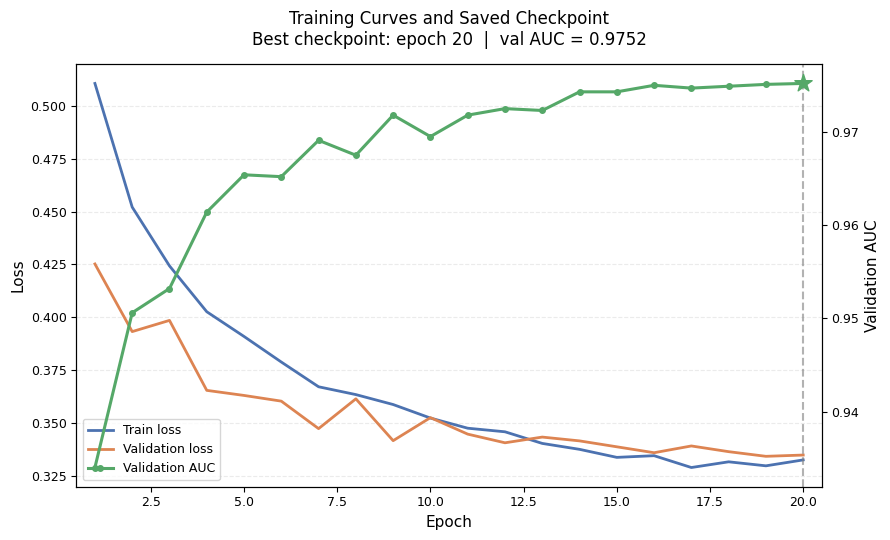

Saved training_curve.png


In [13]:
import matplotlib.pyplot as plt

epochs = history['epoch']  # plain list — use min()/max(), not .min()/.max()

fig, ax1 = plt.subplots(figsize=(9, 5.5))

# -------------------------
# Loss curves
# -------------------------
ax1.plot(epochs, history['train_loss'], label='Train loss', color='#4C72B0', linewidth=2)
ax1.plot(epochs, history['val_loss'], label='Validation loss', color='#DD8452', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_xlim(min(epochs) - 0.5, max(epochs) + 0.5)
ax1.grid(axis='y', linestyle='--', alpha=0.25)

# -------------------------
# Validation AUC
# -------------------------
ax2 = ax1.twinx()
ax2.plot(epochs, history['val_auc'], label='Validation AUC', color='#55A868',
          linewidth=2.2, marker='o', markersize=4)
ax2.set_ylabel('Validation AUC', fontsize=11)

# -------------------------
# Best checkpoint marker — just the visual pointer here, no floating text
# -------------------------
ax1.axvline(best_epoch, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
ax2.scatter([best_epoch], [best_val_auc_from_log], color='#55A868', s=170, zorder=6, marker='*')

# -------------------------
# Combined legend
# -------------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', frameon=True, fontsize=9)

# -------------------------
# Title carries the "best epoch" callout — guaranteed empty space, so it
# never overlaps the curves or legend the way a floating annotation can.
# -------------------------
ax1.set_title(
    f'Training Curves and Saved Checkpoint\n'
    f'Best checkpoint: epoch {best_epoch}  |  val AUC = {best_val_auc_from_log:.4f}',
    fontsize=12, pad=14
)

ax1.tick_params(axis='both', labelsize=9)
ax2.tick_params(axis='y', labelsize=9)

fig.tight_layout()
plt.savefig('training_curve.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved training_curve.png")

## 6. Evaluate: clean vs. transformed (robustness table deliverable)

Now evaluated on the full held-out 30% test split from Section 4 (not a small 200-per-class subsample), including WEBP/PNG robustness conditions that weren't measured before.


In [14]:
def evaluate(model, samples, transform_fn, batch_size=64):
    model.eval()
    all_labels, all_scores = [], []
    batch_imgs, batch_labels = [], []

    def flush():
        if not batch_imgs:
            return
        x = torch.stack(batch_imgs).to(device)
        scores = torch.softmax(model(x), dim=1)[:, 1].cpu().tolist()
        all_scores.extend(scores)
        all_labels.extend(batch_labels)
        batch_imgs.clear()
        batch_labels.clear()

    with torch.no_grad():
        for item, label in samples:
            img = transform_fn(load_and_fix(item))
            batch_imgs.append(base_preprocess(img.convert('RGB')))
            batch_labels.append(label)
            if len(batch_imgs) >= batch_size:
                flush()
        flush()

    preds = [1 if s > 0.5 else 0 for s in all_scores]
    return accuracy_score(all_labels, preds), roc_auc_score(all_labels, all_scores)


print(f'Evaluating on the full held-out test set: {len(all_test_samples)} images '
      f'(the 30% test split from Section 4, never seen during training)\n')

print(f'{"Condition":<20} {"Acc":<10} {"AUC":<10}')
robustness_table = []
for name, fn in EVAL_TRANSFORMS.items():
    acc, auc = evaluate(model, all_test_samples, fn)
    print(f'{name:<20} {acc:<10.3f} {auc:<10.3f}')
    robustness_table.append({'condition': name, 'accuracy': round(acc, 4), 'auc': round(auc, 4)})

with open('robustness_table.json', 'w') as f:
    json.dump(robustness_table, f, indent=2)
print('\nSaved robustness_table.json — this is your Robustness Evaluation Summary deliverable')

# Per-source clean-condition breakdown — useful for spotting whether one
# generator/domain (e.g. Midjourney+) is dragging the combined average down,
# which tells you where to add more data.
print('\nPer-source clean-condition breakdown:')
for src_name, src_samples in test_samples_by_source.items():
    acc, auc = evaluate(model, src_samples, EVAL_TRANSFORMS['clean'])
    print(f'{src_name:<12} n={len(src_samples):<6} acc: {acc:.3f}  auc: {auc:.3f}')


Evaluating on the full held-out test set: 13500 images (the 30% test split from Section 4, never seen during training)

Condition            Acc        AUC       
clean                0.916      0.973     
jpeg_q30             0.894      0.957     
webp_q70             0.910      0.969     
png_roundtrip        0.916      0.973     
blur_s2.0            0.844      0.919     
resize_0.25x         0.826      0.907     
noise_s0.10          0.861      0.931     
color_jitter         0.908      0.968     
center_crop_80       0.879      0.950     

Saved robustness_table.json — this is your Robustness Evaluation Summary deliverable

Per-source clean-condition breakdown:
CIFAKE       n=10800  acc: 0.920  auc: 0.977
SID_Set      n=900    acc: 0.802  auc: 0.949
Midjourney+  n=1800   acc: 0.948  auc: nan


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


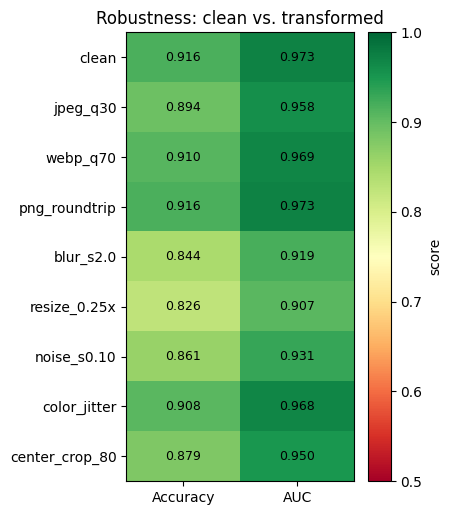

Saved robustness_heatmap.png — this is your Robustness Evaluation Summary visual.


In [15]:
import matplotlib.pyplot as plt
import numpy as np

conditions = [r['condition'] for r in robustness_table]
matrix = np.array([[r['accuracy'], r['auc']] for r in robustness_table])

fig, ax = plt.subplots(figsize=(4.5, 0.45 * len(conditions) + 1.2))
im = ax.imshow(matrix, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Accuracy', 'AUC'])
ax.set_yticks(range(len(conditions)))
ax.set_yticklabels(conditions)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f'{matrix[i, j]:.3f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='score')
plt.title('Robustness: clean vs. transformed')
plt.tight_layout()
plt.savefig('robustness_heatmap.png', dpi=150)
plt.show()
print("Saved robustness_heatmap.png — this is your Robustness Evaluation Summary visual.")


## 7. Run inference on your own images + save submission JSON

Upload any images to test — real photos, AI art, screenshots, anything. Select multiple files at once in the upload dialog if you want to test a batch.

In [16]:
from google.colab import files

os.makedirs('sample_images', exist_ok=True)
uploaded = files.upload()
for fname in uploaded.keys():
    os.rename(fname, os.path.join('sample_images', fname))

def predict(img: Image.Image) -> float:
    img = ImageOps.exif_transpose(img).convert('RGB')  # fix: phone photos are often
                                                         # stored sideways via EXIF tag
    x = base_preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        return torch.softmax(model(x), dim=1)[0, 1].item()

image_paths = sorted(glob.glob('sample_images/*'))
submission = []
for p in image_paths:
    try:
        img = Image.open(p)
    except Exception as e:
        print(f'Skipping {p}: {e}')
        continue
    score = predict(img)
    submission.append({'image_path': p, 'pred': round(score, 4)})
    print(f'{p}: {score:.4f}')

with open('results.json', 'w') as f:
    json.dump(submission, f, indent=2)
print('\nSaved results.json (required submission format)')


Saving bruno1 to bruno1
Saving Codex Image Aug 31, 2026, 02_03_56 AM.png to Codex Image Aug 31, 2026, 02_03_56 AM.png
Saving fruit to fruit
Saving fruit1.jpeg to fruit1.jpeg
Saving kim jong un.jpeg to kim jong un.jpeg
Saving kim jong un2.jpeg to kim jong un2.jpeg
Saving neil armstronf.jpg to neil armstronf.jpg
Saving orange to orange
Saving windows.jpg to windows.jpg
sample_images/Codex Image Aug 31, 2026, 02_03_56 AM.png: 0.7691
sample_images/bruno1: 0.9295
sample_images/fruit: 0.5367
sample_images/fruit1.jpeg: 0.4879
sample_images/kim jong un.jpeg: 0.9725
sample_images/kim jong un2.jpeg: 0.7277
sample_images/neil armstronf.jpg: 0.7190
sample_images/orange: 0.7691
sample_images/windows.jpg: 0.9931

Saved results.json (required submission format)


## Notes
- Re-running Section 7 any time reuses your already-trained `model` in memory — no need to retrain.
- Only re-run Section 2 if you've restarted your Colab runtime (which wipes all downloaded/streamed data).